# Using ROCS Scorer in DrugEx RNN

how to integrate the ROCS scorer into a DrugEx RNN workflow

- Configuring both CPU‑fallback (ez_rocs) and GPU‑accelerated (fastrocs) scorers with an .sq query  
- Scoring and visualizing example SMILES  
- Building a multi‑objective environment combining ROCS similarity and synthetic‑accessibility  
- Fine‑tuning and reinforcement‑learning of an RNN generator  
- Evaluating generated molecules (desired count, average scores, top hits) and comparing GPU vs. CPU performance  

## Prerequisites

To run this notebook, you need:
1. The DrugEx package installed
2. OpenEye toolkit with a valid license
3. A ROCS query file (.sq format)

## 1. Setting Up ROCS Scorer



In [2]:
from drugex.training.scorers.ez_rocs import RocsScorer
from drugex.training.scorers.fastrocs import OpenEyeScorer
import os
from rdkit.Chem import PandasTools
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Path to your ROCS query file (.sq format)
# Get the absolute path to your model files
current_dir = Path(os.path.dirname(os.path.abspath("__file__")))  # Gets notebook directory
models_dir = current_dir / "models"

# List all .sq files and convert to absolute paths
sq_files = [str(f.absolute()) for f in models_dir.glob("*.sq")]

print(f"Found {len(sq_files)} ROCS query files:")
for i, f in enumerate(sq_files):
    print(f"  {i+1}. {os.path.basename(f)}")




OpenEye memory pool initialized in ez_rocs module
Found 6 ROCS query files:
  1. 3.sq
  2. 1.sq
  3. 5.sq
  4. model3-4_v1.sq
  5. 2.sq
  6. 4.sq


In [3]:
# choose just models with name '3.sq' and '4.sq'
sq_files = [f for f in sq_files if os.path.basename(f).startswith('3.sq') or os.path.basename(f).startswith('4.sq')]
print(sq_files)

['/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/models/3.sq', '/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/tutorial/rocs/models/4.sq']


In [4]:
sq_files = ['models/5.sq','models/1.sq','models/3.sq', 'models/4.sq']

# Initialize the ROCS scorer
ez_rocs_scorer = RocsScorer(
    query_file=sq_files,                # Path to the .sq model file
    experiment_name="ccr2_experiment",   # Name for temporary files
    score_type="TanimotoCombo",         # Type of score to extract (TanimotoCombo, ShapeTanimoto, or ColorTanimoto)
    use_gpu=True,
    max_isomers=4,
    max_rot_bonds=15,
    max_heavy_atoms=45,
    max_conformers=10,   # number of conformers to generate per molecule
    cpu_processes=1,     # this is used when use_gpu is False
    
    # top_n_models=2,      # Number of top performing models to use for scoring. Models are ranked by their 
                        # exponential moving average scores, which are updated based on scoring results
                        # from small batches of molecules. This allows the scorer to adaptively focus
                        # on the most effective models during training.
    
    # parallel_execution=True  # always True - whether to score with multiple models in parallel
)

fastrocs_scorer = OpenEyeScorer(
    sq_model_path=sq_files,
    use_gpu=True,           # when use_gpu is False, will all available CPU -2 !!!! This can cause OOM error
    max_isomers=4,
    max_rot_bonds=15,
    max_heavy_atoms=45,
    max_conformers=10,
)


ROCS scorer initialized using GPU mode with 4 shape query files
FastROCS GPU mode   : ON  (single process)


In [5]:
from openeye import oefastrocs
print("GPU ready?", oefastrocs.OEFastROCSIsGPUReady())

GPU ready? True


## 1. ROCS Scorer Configuration

## 2. Molecule Scoring Comparison

In [6]:
# Example SMILES strings to score

test_smiles = [
    "O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1ccc(Cl)c(Cl)c1",  
    "CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2)[n-]c1=S",  
]
# Get scores for the molecules
scores = fastrocs_scorer.getScores(test_smiles)

# Display the scores
for smi, score in zip(test_smiles, scores):
    print(f"SMILES: {smi}\nfastrocs_Score: {score:.4f}\n")

# Create a DataFrame for easier visualization
results_df = pd.DataFrame({
    'SMILES': test_smiles,
    'fastrocs_Score': scores
})
results_df

FALLBACK: Some molecules lack conformers, using OMEGA only for those.
Generated 10 conformers from 2 molecules
Preparing 10 molecules for GPU processing...
Generated 10 conformers from 2 molecules
Preparing 10 molecules for GPU processing...
Generated 10 conformers from 2 molecules
Preparing 10 molecules for GPU processing...
Generated 10 conformers from 2 molecules
Preparing 10 molecules for GPU processing...
SMILES: O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1ccc(Cl)c(Cl)c1
fastrocs_Score: 0.5145

SMILES: CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2)[n-]c1=S
fastrocs_Score: 0.7688



,SMILES,fastrocs_Score
0,O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1c...,0.514528
1,CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2...,0.768813


In [7]:
# Example SMILES strings to score

test_smiles = [
    "O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1ccc(Cl)c(Cl)c1",  
    "CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2)[n-]c1=S",  
]
# Get scores for the molecules
scores = ez_rocs_scorer.getScores(test_smiles)

# Display the scores

for smi, score in zip(test_smiles, scores):
    print(f"SMILES: {smi}\nez_rocs Score: {score:.4f}\n")

# Create a DataFrame for easier visualization
results_df = pd.DataFrame({
    'SMILES': test_smiles,
    'ez_rocs_Score': scores
})
results_df

OMEGA generated conformers for 2 molecules
Scoring with query: 5.sq
Wrote 2 scores for query 5.sq
OMEGA generated conformers for 2 molecules
Scoring with query: 1.sq
Wrote 2 scores for query 1.sq
OMEGA generated conformers for 2 molecules
Scoring with query: 3.sq
Wrote 2 scores for query 3.sq
OMEGA generated conformers for 2 molecules
Scoring with query: 4.sq
Wrote 2 scores for query 4.sq
SMILES: O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1ccc(Cl)c(Cl)c1
ez_rocs Score: 0.5970

SMILES: CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2)[n-]c1=S
ez_rocs Score: 0.8543



,SMILES,ez_rocs_Score
0,O=C([O-])c1ccccc1Oc1ccc(Cl)cc1[N-]S(=O)(=O)c1c...,0.596977
1,CC[C@@H](c1ccc(F)c(F)c1)n1c(C(=O)OC)c(-c2ccno2...,0.854343


### 2.1 FastROCS Results



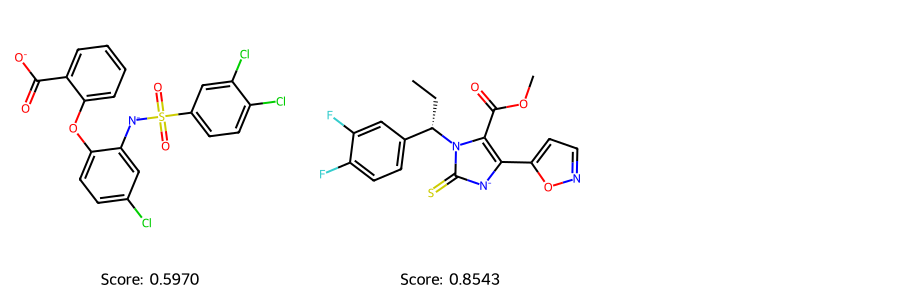

In [8]:
from rdkit import Chem
from rdkit.Chem import Draw

# Convert SMILES to RDKit molecules
mols = [Chem.MolFromSmiles(smi) for smi in test_smiles]

# Create labels with scores
legends = [f"Score: {score:.4f}" for score in scores]

# Display molecules with their scores
img = Draw.MolsToGridImage(mols, molsPerRow=3, legends=legends, subImgSize=(300, 300))
img

In [9]:
### 2.2 Smart CLI ROCS Integration

# Import Smart CLI ROCS Scorer
from drugex.training.scorers.smart_cli_rocs import SmartCLIROCSScorer

# Configure Smart CLI ROCS scorer
smart_cli_scorer = SmartCLIROCSScorer(
    query_files=sq_files,
    max_conformers=10,
    max_isomers=4,
    max_heavy_atoms=45,
    max_rotatable_bonds=15,
    shape_only=False,
    rocs_binary="rocs"
)

print("✅ Smart CLI ROCS Scorer configured successfully")


✅ Smart CLI ROCS Scorer configured successfully


## 3. DrugEx Integration

Multi-objective optimization with:
- ROCS similarity (maximize)
- Synthetic accessibility (minimize)

In [10]:
# Import additional required modules
from drugex.training.environment import DrugExEnvironment
from drugex.training.scorers.modifiers import SmoothClippedScore
from drugex.training.rewards import ParetoCrowdingDistance
from drugex.training.scorers.properties import Property
from drugex.data.corpus.vocabulary import VocSmiles
from drugex.training.generators import SequenceRNN

# Path to pretrained model (adjust as needed)
GPUS = [0]  # Use GPU 0
MODELS_PATH = "../data/models/pretrained/smiles-rnn/Papyrus05.5_smiles_rnn_PT"

voc = VocSmiles.fromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.vocab', encode_frags=False)

# Load pretrained model
pretrained = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
pretrained.loadStatesFromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.pkg')


/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/drugex/training/interfaces.py:312: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.loadStates(torch.load(path, map_l

In [11]:
# Synthetic Accessibility Scorer (1-10 scale, lower = better)
sa_scorer = Property("SA")
sa_scorer.setModifier(SmoothClippedScore(lower_x=5, upper_x=3))  # Matches your graph

# ROCS Combo Scorer (0-2 scale, higher = better)
# rocs_scorer = Property("ROCS")
# rocs_scorer.setModifier(SmoothClippedScore(lower_x=0.5, upper_x=1.5))  # Prioritize scores 0.5-1.5

# Calculate normalized threshold for desired real ROCS ≥ 1.0
# Formula: (real_score - lower_x) / (upper_x - lower_x)
rocs_threshold = (1.0 - 0.5) / (1.5 - 0.5)  # = 0.5

# Thresholds in normalized scores (0-1)
thresholds = [
    0.35,    # ROCS: Real score ≥1.0 → normalized 0.5
    0.1     # SA: Real score ≤3.9 → normalized 0.3
]


In [12]:
# --------------------------
# Multi-Objective Optimization
# --------------------------
scorer_ez = [ez_rocs_scorer, sa_scorer]
scorer_fastrocs = [fastrocs_scorer, sa_scorer]
scorer_smart_cli = [smart_cli_scorer, sa_scorer]


### Environment Selection

Available environments:
- **scorer_ez**: EZ ROCS + SA score 
- **scorer_fastrocs**: FastROCS + SA score (GPU optimized)
- **scorer_smart_cli**: Smart CLI ROCS + SA score (intelligent preprocessing)


In [13]:
# Create environment with Pareto optimization
env = DrugExEnvironment(
    scorers=scorer_fastrocs,  # scorer_fastrocs, scorer_ez, scorer_smart_cli
    thresholds=thresholds,
    reward_scheme=ParetoCrowdingDistance()  # Multi-objective optimization scheme
)

# Test Smart CLI ROCS in DrugEx environment
print("Testing Smart CLI ROCS in DrugEx environment...")
env_smart = DrugExEnvironment(
    scorers=scorer_smart_cli,
    thresholds=thresholds,
    reward_scheme=ParetoCrowdingDistance()
)
smart_test_scores = env_smart.getScores(test_smiles)
print(f"Smart CLI Environment working: {len(smart_test_scores) > 0}")

Testing Smart CLI ROCS in DrugEx environment...
Starting ROCS scoring for 2 molecules...
  ROCS execution: 4.3s
  ROCS execution: 4.3s
  ROCS execution: 4.3s
  ROCS execution: 4.3s
ROCS scoring completed in 17.5s
Smart CLI Environment working: True


## 4. DrugEx Training

In [14]:
from drugex.data.processing import CorpusEncoder, RandomTrainTestSplitter, Standardization
from drugex.training.explorers import SequenceExplorer
from drugex.training.monitors import FileMonitor
import multiprocessing as mp
from drugex.data.corpus.corpus import SequenceCorpus
from drugex.data.datasets import SmilesDataSet


CPU_COUNT     = max(1, mp.cpu_count() - 2)  
MODEL_DIR_RL = "./rocs_rl_ccr"
if not os.path.exists(MODEL_DIR_RL):
    os.makedirs(MODEL_DIR_RL)
    
    
print(f"Fine-tuning device: {'GPU' if GPUS else 'CPU'} (GPUS: {GPUS})")

voc = VocSmiles.fromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.vocab', encode_frags=False)
pretrained = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
pretrained.loadStatesFromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.pkg')
data_path = "CCR_HUMAN_AL.tsv"
print(f"Loading fine-tuning data from {data_path}")
df = pd.read_csv(data_path, sep='\t')



Fine-tuning device: GPU (GPUS: [0])
Loading fine-tuning data from CCR_HUMAN_AL.tsv


/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/drugex/training/interfaces.py:312: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.loadStates(torch.load(path, map_l

In [15]:
if 'SMILES' not in df.columns:
    print(f"ERROR: No 'SMILES' column found in {data_path}")



X_train = df['SMILES'].values
model = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
model.load_state_dict(pretrained.state_dict())

CHUNK_SIZE = 1024
BATCH_SIZE = 512
FT_EPOCHS = 100

standardizer = Standardization(n_proc=CPU_COUNT, chunk_size=CHUNK_SIZE)
valid_smiles = standardizer.apply(X_train)
print(f"Found {len(valid_smiles)} valid SMILES strings for training")
os.makedirs(MODEL_DIR_RL, exist_ok=True)
corpus_file = os.path.join(MODEL_DIR_RL, "corpus.tsv")
voc_file = os.path.join(MODEL_DIR_RL, "model.vocab")
encoder = CorpusEncoder(
    SequenceCorpus,
    {'vocabulary': voc, 'update_voc': False, 'throw': True},
    n_proc=CPU_COUNT,
    chunk_size=CHUNK_SIZE
)

Standardizing molecules (batch processing):   0%|          | 0/1 [00:00<?, ?it/s]

Found 1021 valid SMILES strings for training


In [16]:
data_collector = SmilesDataSet(corpus_file, rewrite=True)
encoder.apply(valid_smiles, collector=data_collector)
voc.toFile(voc_file)

print(f"Saved vocabulary to {voc_file}")
splitter = RandomTrainTestSplitter(0.05, 1e4)
train, test = splitter(data_collector.getData())
for data, name in zip([train, test], ['train', 'test']):
    pd.DataFrame(data, columns=data_collector.getColumns()).to_csv(
        os.path.join(MODEL_DIR_RL, f'ligand_{name}.tsv'),
        header=True, index=False, sep='\t'
    )

SequenceCorpus (batch processing):   0%|          | 0/1 [00:00<?, ?it/s]

Molecule does not meet min/max words requirements (min: 10, max: 100). Words found: {'N', ')', '3', '2', 'L', 'C', '1', '(', 'S', 'F', 'EOS', '=', 'c', 'O'} (occurrence count: 102). It will be ignored.


Saved vocabulary to ./rocs_rl_ccr/model.vocab


### 4.1 Fine-tuning

In [18]:
# data_set_train = SmilesDataSet(os.path.join(MODEL_DIR_RL, 'ligand_train.tsv'), voc=voc)
# train_loader = data_set_train.asDataLoader(batch_size=BATCH_SIZE)
# data_set_test = SmilesDataSet(os.path.join(MODEL_DIR_RL, 'ligand_test.tsv'), voc=voc)
# valid_loader = data_set_test.asDataLoader(batch_size=BATCH_SIZE)
# print(f"Fine-tuning model for {FT_EPOCHS} epochs")

# model.fit(train_loader, valid_loader, epochs=FT_EPOCHS,
#              monitor=FileMonitor(
#                  f"{MODEL_DIR_RL}/finetune", 
#                  save_smiles=True,
#                  reset_directory=True
#                  ))

# os.makedirs(MODEL_DIR_RL, exist_ok=True)
# model_path = f'{MODEL_DIR_RL}/finetune.pkg'
# voc.toFile(f'{MODEL_DIR_RL}/finetune.vocab')
# print(f"Model saved to {model_path}")
# print("Fine-tuning completed successfully")


Removing finetune_smiles.tsv from ./rocs_rl_ccr
Removing finetune.pkg from ./rocs_rl_ccr
Removing finetune.vocab from ./rocs_rl_ccr
Removing finetune_fit.log from ./rocs_rl_ccr
Removing finetune_fit.tsv from ./rocs_rl_ccr


Fine-tuning model for 100 epochs


Fitting model:   0%|          | 0/100 [00:00<?, ?it/s]

Model saved to ./rocs_rl_ccr/finetune.pkg
Fine-tuning completed successfully


### 4.2 Reinforcement Learning



In [19]:
try:
    vocab_path = f'{MODEL_DIR_RL}/finetune.vocab'
    voc = VocSmiles.fromFile(vocab_path, encode_frags=False)
except FileNotFoundError:
    print("Finetuned vocabulary not found, using pretrained vocabulary instead")
    voc = VocSmiles.fromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.vocab', encode_frags=False)

try:
    finetuned = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
    finetuned.loadStatesFromFile(f'{MODEL_DIR_RL}/finetune.pkg')
except FileNotFoundError:
    print("Finetuned model not found, using pretrained model instead")
    finetuned = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
    finetuned.loadStatesFromFile(f'{MODELS_PATH}/Papyrus05.5_smiles_rnn_PT.pkg')


/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/drugex/training/interfaces.py:312: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.loadStates(torch.load(path, map_l

In [20]:
explorer = SequenceExplorer(
    agent=finetuned,
    env=env_smart,
    mutate=pretrained,
    epsilon=0.1,
    batch_size=600,
    n_samples=600,
    use_gpus=GPUS
)

# Set up output directory for training logs
os.makedirs(MODEL_DIR_RL, exist_ok=True)

# Configure monitor to track progress
monitor = FileMonitor(
    f"{MODEL_DIR_RL}/rocs_agent", 
    save_smiles=True,          # Save generated SMILES
    reset_directory=True       # Clear previous results
)

Removing rocs_agent_fit.log from ./rocs_rl_ccr
Removing rocs_agent_fit.tsv from ./rocs_rl_ccr
Removing rocs_agent_smiles.tsv from ./rocs_rl_ccr
Removing rocs_agent.pkg from ./rocs_rl_ccr


### 4.3 Model Training


In [ ]:
# Run reinforcement learning (in practice, use more epochs, e.g., 30-100)
explorer.fit(monitor=monitor, epochs=40, patience=10)

# Load training progress
training_df = pd.read_csv(f"{MODEL_DIR_RL}/rocs_agent_fit.tsv", sep='\t')


In [22]:
training_df.head(50)

,Epoch,valid_ratio,unique_ratio,desired_ratio,avg_amean,avg_gmean,loss_train,best_epoch
0,1,0.817,0.800,0.667,0.662,0.571,0.227,1
1,2,0.767,0.750,0.567,0.622,0.501,0.053,1
2,3,0.650,0.633,0.400,0.602,0.409,0.045,1
3,4,0.867,0.867,0.700,0.672,0.575,0.054,4
4,5,0.817,0.817,0.583,0.615,0.491,0.055,4
5,6,0.800,0.800,0.550,0.628,0.487,0.063,4
6,7,0.933,0.933,0.717,0.655,0.557,0.067,7
7,8,0.917,0.900,0.600,0.636,0.538,0.067,7
8,9,0.950,0.950,0.717,0.687,0.611,0.067,7
9,10,0.917,0.917,0.700,0.675,0.584,0.062,7


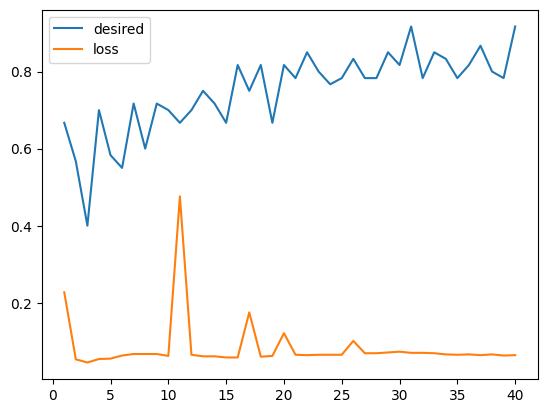

In [23]:
# linear plot of the training progress
plt.plot(training_df['Epoch'], training_df['desired_ratio'], label='desired')
plt.plot(training_df['Epoch'], training_df['loss_train'], label='loss')
plt.legend()
plt.show()


In [17]:
# Load the trained model
optimized_model = SequenceRNN(voc, is_lstm=True, use_gpus=GPUS)
optimized_model.loadStatesFromFile(f"{MODEL_DIR_RL}/rocs_agent.pkg")

# Generate molecules
generated = optimized_model.generate(num_samples=1000)


/home/dodo/Documents/projects/drugex-rocs/DrugEx-ROCS/drugex/training/interfaces.py:312: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.loadStates(torch.load(path, map_l

Generating molecules:   0%|          | 0/1000 [00:00<?, ?it/s]

In [18]:
generated

,SMILES,Valid
0,O=C(O)c1ccc(OCc2ccccc2C(F)(F)F)cc1,1.0
1,CCC(=O)Nc1cccc(OCCCN2CCC(Cc3ccccc3)CC2)c1,1.0
2,CCCCN(C(=O)c1ccc(Cl)cc1)c1ccc(OC)cc1,1.0
3,Cc1csc(COc2cccc(Cl)c2)n1,1.0
4,O=C(COc1ccc(Cl)cc1)NC1CNC(C(=O)O)C1,1.0
...,...,...
995,COc1ccccc1NC(=O)Nc1ccccc1,1.0
996,CCCCCNc1nc(Cl)c2ccccc2n1,1.0
997,COC(=O)c1ccc(CN(Cc2ccccc2)c2cc(Cl)cc(Cl)c2)cc1,1.0
998,O=C(Nc1ccc(Cl)cc1Cl)c1ccccc1,1.0


Starting ROCS scoring for 1000 molecules...
Generating conformers...


.. 100 molecules processed.
.. 200 molecules processed.
.. 300 molecules processed.
.. 400 molecules processed.
.. 500 molecules processed.
.. 600 molecules processed.
.. 700 molecules processed.
.. 800 molecules processed.
.. 900 molecules processed.
.. 1000 molecules processed.

Total: 1000 molecules processed.


  ROCS execution: 7.2s
  ROCS execution: 7.5s
  ROCS execution: 7.3s
  ROCS execution: 7.4s
ROCS scoring completed in 195.8s
=== DEBUGGING SCORES ===
Available columns: ['Valid', 'ROCS', 'SA', 'Desired']
DataFrame shape: (1000, 4)
DataFrame head:
   Valid   ROCS        SA  Desired
0    1.0  0.459  0.989104        1
1    1.0  0.404  0.983928        1
2    1.0  0.525  0.989471        1
3    1.0  0.390  0.984798        1
4    1.0  0.434  0.912180        1

Scorer keys in environment:
  - ROCS
  - SA

=== SUMMARY STATISTICS ===
Generated 1000 molecules
Desirable molecules: 911 (91.1%)
Average ROCS score: 0.4496
Average SA score: 0.9771


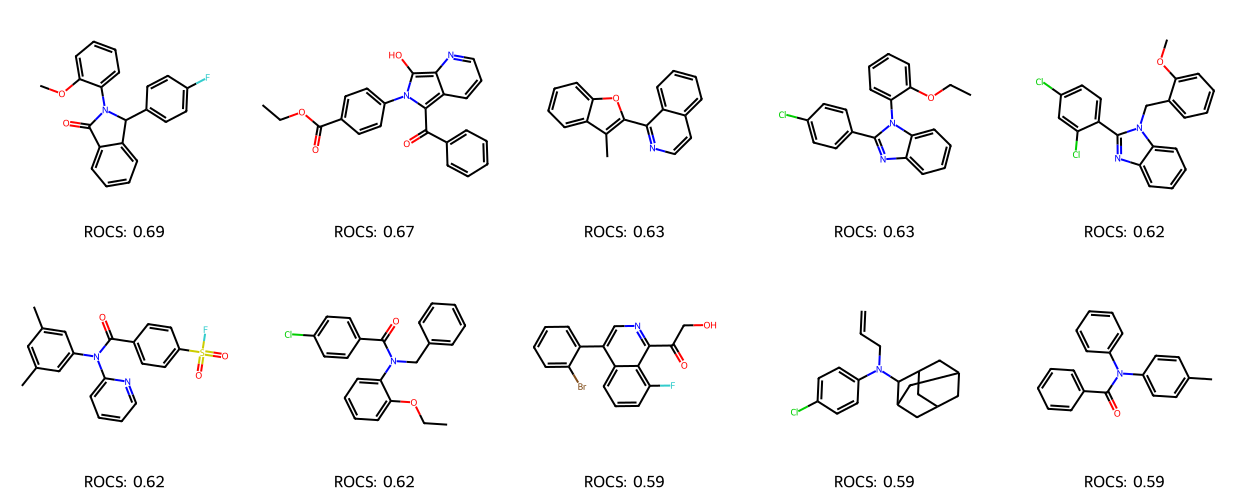

In [19]:
generated_smiles = generated.SMILES.tolist()

# Score the generated molecules
scores = env_smart.getScores(generated_smiles)
scores_df = pd.DataFrame(scores)

# DEBUG: Check what columns exist
print("=== DEBUGGING SCORES ===")
print(f"Available columns: {list(scores_df.columns)}")
print(f"DataFrame shape: {scores_df.shape}")
print(f"DataFrame head:")
print(scores_df.head())

# Check scorer keys
print(f"\nScorer keys in environment:")
for scorer in env_smart.scorers:
    print(f"  - {scorer.getKey()}")

# Display summary statistics
print(f"\n=== SUMMARY STATISTICS ===")
print(f"Generated {len(generated_smiles)} molecules")
print(f"Desirable molecules: {scores_df['Desired'].sum()} ({scores_df['Desired'].mean()*100:.1f}%)")
print(f"Average ROCS score: {scores_df['ROCS'].mean():.4f}")
print(f"Average SA score: {scores_df['SA'].mean():.4f}")

# Show top 10 molecules by ROCS score
top_by_rocs = scores_df.sort_values('ROCS', ascending=False).head(10)
top_indices = top_by_rocs.index.tolist()
top_smiles = [generated_smiles[i] for i in top_indices]
top_scores = top_by_rocs['ROCS'].tolist()

# Convert to RDKit molecules and display
top_mols = [Chem.MolFromSmiles(smi) for smi in top_smiles]
legends = [f"ROCS: {score:.2f}" for score in top_scores]
img = Draw.MolsToGridImage(top_mols, molsPerRow=5, legends=legends, subImgSize=(250, 250))
img